# The AG Share of New Company Registrations in Basel-Landschaft, 2017 vs 2025

**Author:** Mauro Reverberi

**Program:** MSc AI, Udacity Institute of AI & Technology / Woolf

**Project:** Capstone Project 2, Data and Statistical Reasoning

**Dataset:** "Firmenmutationen nach Rechtsform und Gemeinde" (company mutations by legal form and municipality), Open Government Data Kanton Basel-Landschaft:
https://data.bl.ch/explore/dataset/12460/

In this notebook I analyze new company registrations in the Swiss canton of
Basel-Landschaft.

**Research question:** Did the share of stock corporations (Aktiengesellschaft,
AG) among new company registrations in the canton of Basel-Landschaft change
between 2017 and 2025?

I picked this question because it connects to my first capstone project. In
Project 1 I analyzed the Swiss entries of the global LEI dataset and found
that the classic stock corporation (AG / SA) is the largest legal form group
in that register. This made me curious whether the AG also plays such a
strong role when new companies are founded, and whether that role changed
over time. One important point up front, the two projects use different
datasets and different populations. Project 1 looked at the stock of
LEI-registered entities, which is dominated by larger firms. This project
looks at single new registrations published in the Swiss Official Gazette of
Commerce (SHAB) for one canton. The percentages from the two projects must
not be compared directly.

## Dataset

The frozen snapshot `firmenmutationen.csv` is stored in the same folder as
this notebook. I downloaded it on 2026-08-13 through the direct CSV export:
https://data.bl.ch/explore/dataset/12460/download/?format=csv

The snapshot covers the period 2016-02-03 to 2026-08-12.

One row in this dataset is one single mutation message published in the
SHAB, so the data is not aggregated. The observation unit of my analysis is
one published new company registration. The online dataset is updated
continuously, so I froze a local copy and the notebook only reads this
local file. The publisher documents two known quality issues, the
municipality columns are partly incomplete and the free text field
`meldung` contains encoding errors. Both fields are not needed for my
research question.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

## Load the dataset

I load the frozen CSV with a semicolon separator and check that the structure looks right before I touch anything.

In [2]:
df = pd.read_csv("firmenmutationen.csv", sep=";", encoding="utf-8")
df.head()

,kategorie,publikationsdatum_shab,journaldatum_handelsregister,id_shab,firmensitz_code,firmensitz,meldung,uid,firmenname,rechtsform_code,rechtsform
0,Neueintragung,2026-08-12,2026-08-07,1006729550,2762.0,Allschwil,"R.K. SanitÃ¤r Rima, in Allschwil, CHE-440.128....",CHE440128482,R.K. Sanitär Rima,101,Einzelunternehmen
1,Neueintragung,2026-08-12,2026-08-07,1006729549,2762.0,Allschwil,"R.K. Elektro Rima, in Allschwil, CHE-380.378.8...",CHE380378843,R.K. Elektro Rima,101,Einzelunternehmen
2,Neueintragung,2026-08-12,2026-08-07,1006729548,2834.0,Ziefen,"MS Swiss Handel GmbH, in Ziefen, CHE-285.436.8...",CHE285436803,MS Swiss Handel GmbH,107,Gesellschaft mit beschränkter Haftung (GmbH)
3,Löschung,2026-08-12,2026-08-07,1006729555,2824.0,Frenkendorf,"OlaVintage, Inhaber John Jairo Lopez, in Frenk...",CHE354942212,"OlaVintage, Inhaber John Jairo Lopez",101,Einzelunternehmen
4,Löschung,2026-08-12,2026-08-07,1006729554,2761.0,Aesch (BL),"MB Car Cleaning Jeyson Benitez Gomez, in Aesch...",CHE363228510,MB Car Cleaning Jeyson Benitez Gomez,101,Einzelunternehmen


The first rows look as expected, one register message per row with the mutation category, two dates, the company name, the legal form and a long free text field. The encoding problem the publisher mentions is directly visible, `meldung` shows broken characters like "SanitÃ¤r" while the separate `firmenname` column shows the correct "Sanitär". So the problem is only in the free text field, which I do not use.


In [3]:
print(f"Rows: {df.shape[0]}, columns: {df.shape[1]}")
df.info()

Rows: 28992, columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 28992 entries, 0 to 28991
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   kategorie                     28992 non-null  str    
 1   publikationsdatum_shab        28992 non-null  str    
 2   journaldatum_handelsregister  28992 non-null  str    
 3   id_shab                       28992 non-null  int64  
 4   firmensitz_code               28882 non-null  float64
 5   firmensitz                    28882 non-null  str    
 6   meldung                       28992 non-null  str    
 7   uid                           28992 non-null  str    
 8   firmenname                    28992 non-null  str    
 9   rechtsform_code               28992 non-null  int64  
 10  rechtsform                    28992 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 2.4 MB


The file has 28,992 rows and 11 columns, which matches the download page. Three columns are numeric (`id_shab`, `firmensitz_code`, `rechtsform_code`), all of them are identifiers or codes. The two date columns are loaded as strings, so I will convert the publication date later. Nothing needs fixing at this point.

## Data checks

Before I filter anything I want to know how complete the data is, whether rows are duplicated and which values the two key columns `kategorie` and `rechtsform` actually contain.

In [4]:
df.isna().sum()

kategorie                         0
publikationsdatum_shab            0
journaldatum_handelsregister      0
id_shab                           0
firmensitz_code                 110
firmensitz                      110
meldung                           0
uid                               0
firmenname                        0
rechtsform_code                   0
rechtsform                        0
dtype: int64

Only the two municipality columns have missing values, 110 each. These are exactly the columns the publisher flags as partly incomplete. My analysis uses the mutation category, the legal form and the publication date, and all three are complete, so I do not drop or fill anything.

In [5]:
print("Complete duplicate rows:", df.duplicated().sum())
print("id_shab values are unique:", df["id_shab"].is_unique)

Complete duplicate rows: 0
id_shab values are unique: True


There are no complete duplicate rows and the SHAB message id is unique, so every row is one distinct register message.

In [6]:
df["kategorie"].value_counts()

kategorie
Neueintragung                13124
Löschung                      8356
Auflösung                     2704
Auflösung infolge Konkurs     1872
Widerruf der Auflösung        1767
Fusion                         566
Löschung infolge Fusion        549
Wiedereintragung                31
Spaltung                        23
Name: count, dtype: int64

The dataset covers nine mutation categories. My question is only about new company registrations, so the 13,124 rows with the category "Neueintragung" are the relevant subset. Deletions, mergers and the other categories describe events in the life of existing companies and are out of scope.

In [7]:
df["rechtsform"].value_counts()

rechtsform
Gesellschaft mit beschränkter Haftung (GmbH)           11272
Einzelunternehmen                                      10624
Aktiengesellschaft (AG)                                 5024
Kollektivgesellschaft (KlG)                              647
Zweigniederlassung                                       557
Stiftung                                                 336
Verein                                                   280
Genossenschaft                                           122
Zweigniederlassung eines ausländischen Unternehmens       85
Kommanditgesellschaft (KmG)                               40
Institut des öffentlichen Rechts                           3
Haupt von Gemeinderschaft                                  2
Name: count, dtype: int64

The legal form column has twelve clean values and no spelling variants. The exact label I need for the AG flag is "Aktiengesellschaft (AG)", and I take this string directly from the output above instead of guessing it.

## Cleaning

In this section I prepare the data in three small steps. I convert the
publication date from string to datetime, I reduce the data to the rows my
research question is about, and I add a flag column that marks the AG
registrations. Each step prints a small check, so nothing changes silently.

In [8]:
# convert the SHAB publication date from string to datetime and derive the year
df["publication_date"] = pd.to_datetime(df["publikationsdatum_shab"], errors="coerce")
df["year"] = df["publication_date"].dt.year

print("Dates that failed to convert:", df["publication_date"].isna().sum())
print("Date range:", df["publication_date"].min().date(), "to", df["publication_date"].max().date())

Dates that failed to convert: 0
Date range: 2016-02-03 to 2026-08-12


All 28,992 dates convert without a single failure, and the range confirms the note on the dataset page, the data starts in February 2016 and the current year is still running. Both border years are incomplete, so a fair yearly comparison must exclude them.

In [9]:
# keep only new company registrations, all other mutation types are out of scope
new_regs = df[df["kategorie"] == "Neueintragung"].copy()

print("New registrations in total:", len(new_regs))
print("UID values are unique within the new registrations:", new_regs["uid"].is_unique)

New registrations in total: 13124
UID values are unique within the new registrations: True


The UID is the official company identifier in Switzerland. Inside the 13,124 new registrations every UID appears exactly once, so no company shows up with a second registration in the covered period and I do not need any deduplication. One row really is one newly registered company.

In [10]:
# keep only the complete years, 2016 and 2026 are partial and would distort the comparison
new_regs = new_regs[new_regs["year"].between(2017, 2025)].copy()

print("New registrations 2017 to 2025:", len(new_regs))

New registrations 2017 to 2025: 11267


11,267 new registrations remain. I excluded rows for only two documented reasons. Rows with other mutation categories are outside the research question, and the years 2016 and 2026 are incomplete and would distort a yearly comparison. No rows were removed for quality reasons.

In [11]:
# flag the AG registrations, the basis for all share calculations below
new_regs["is_ag"] = new_regs["rechtsform"] == "Aktiengesellschaft (AG)"
print("AG registrations 2017 to 2025:", int(new_regs["is_ag"].sum()))

AG registrations 2017 to 2025: 1549


The flag `is_ag` marks the 1,549 AG registrations. With this the data preparation is done and I can start describing the data.

## Descriptive statistics

In this section I describe the cleaned data step by step. I start with the
standard summary statistics, then I look at how the registrations spread
over the years, and finally at the legal form counts and the AG share per
year. After each output I write down what I see in it.

In [12]:
new_regs.describe()

,id_shab,firmensitz_code,rechtsform_code,publication_date,year
count,1.126700e+04,11267.000000,11267.000000,11267,11267.000000
mean,8.365007e+08,2799.345167,105.517085,2021-09-12 06:37:59.435519,2021.200586
min,3.261673e+06,2761.000000,101.000000,2017-01-05 00:00:00,2017.000000
25%,1.004658e+09,2767.000000,101.000000,2019-06-24 00:00:00,2019.000000
50%,1.005309e+09,2775.000000,106.000000,2021-10-11 00:00:00,2021.000000
75%,1.005911e+09,2829.000000,107.000000,2023-12-15 00:00:00,2023.000000
max,1.006527e+09,2895.000000,151.000000,2025-12-30 00:00:00,2025.000000
std,3.751453e+08,38.563283,7.680831,NaN,2.585905


`describe()` on the raw columns shows that the original numeric columns are identifiers and codes, their means have no meaning. The quantitative variable of my analysis is the derived `year` column. It comes from the publication date, it is a real numeric time variable and the whole comparison runs on it, so I describe its distribution properly next.

In [13]:
new_regs["year"].describe().round(2)

count    11267.00
mean      2021.20
std          2.59
min       2017.00
25%       2019.00
50%       2021.00
75%       2023.00
max       2025.00
Name: year, dtype: float64

The 11,267 registrations spread over the years 2017 to 2025. The mean year is 2021.20 with a standard deviation of 2.59 years and because the mean sits slightly above the middle year 2021, the later years must hold a bit more registrations. That fits the growing yearly volume. The quartiles at 2019, 2021 and 2023 tell me that the registrations spread quite evenly over the window, no single year dominates. I look at the exact counts per year next.

In [14]:
yearly_counts = new_regs.groupby("year").size()
yearly_counts

year
2017    1156
2018    1106
2019    1128
2020    1237
2021    1256
2022    1265
2023    1371
2024    1304
2025    1444
dtype: int64

In [15]:
yearly_counts.describe().round(2)

count       9.00
mean     1251.89
std       111.83
min      1106.00
25%      1156.00
50%      1256.00
75%      1304.00
max      1444.00
dtype: float64

The number of new registrations per year moves between 1,106 (2018) and 1,444 (2025), with a mean of 1,251.9 and a standard deviation of 111.8 registrations. The general direction is upwards and 2025 is the strongest year in the whole window. This growth matters for my question because a share can fall even when the absolute AG numbers stay flat.

In [16]:
form_counts = new_regs["rechtsform"].value_counts()
form_shares = (form_counts / len(new_regs) * 100).round(2)
pd.DataFrame({"count": form_counts, "share_pct": form_shares})

,count,share_pct
rechtsform,,
Gesellschaft mit beschränkter Haftung (GmbH),4496,39.90
Einzelunternehmen,4402,39.07
Aktiengesellschaft (AG),1549,13.75
Kollektivgesellschaft (KlG),299,2.65
Zweigniederlassung,270,2.40
Verein,127,1.13
Stiftung,72,0.64
Genossenschaft,22,0.20
Zweigniederlassung eines ausländischen Unternehmens,18,0.16


Two legal forms dominate the new registrations, the GmbH with 4,496 registrations (39.90%) and the sole proprietorship with 4,402 (39.07%). The AG follows in third place with 1,549 registrations (13.75%). All other forms together stay below 8%. This is a very different picture than the LEI stock I analyzed in Project 1, where the AG was the largest group, and it confirms why I do not compare the two populations directly.

In [17]:
ag_per_year = new_regs.groupby("year").agg(registrations=("is_ag", "size"), ag_registrations=("is_ag", "sum"))
ag_per_year["ag_share_pct"] = (ag_per_year["ag_registrations"] / ag_per_year["registrations"] * 100).round(2)
ag_per_year

,registrations,ag_registrations,ag_share_pct
year,,,
2017,1156,185,16.00
2018,1106,157,14.20
2019,1128,154,13.65
2020,1237,193,15.60
2021,1256,177,14.09
2022,1265,163,12.89
2023,1371,175,12.76
2024,1304,161,12.35
2025,1444,184,12.74


The AG share starts at 16.00% in 2017 and ends at 12.74% in 2025. The fall is not a straight line, in 2020 the share jumps back to 15.60% before it drops to its lowest value of 12.35% in 2024. The absolute AG numbers barely move (185 in 2017, 184 in 2025), so the falling share is driven by the growing total, not by fewer AG foundations. That was the most surprising pattern in the whole analysis for me.

In [18]:
comparison = ag_per_year.loc[[2017, 2025]]
comparison

,registrations,ag_registrations,ag_share_pct
year,,,
2017,1156,185,16.00
2025,1444,184,12.74


This table puts the two comparison years side by side. 2017 had 1,156 new registrations of which 185 were AG (16.00%). 2025 had 1,444 new registrations of which 184 were AG (12.74%). The observed difference is -3.26 percentage points. Whether a difference of this size can be explained by chance alone is the question for the hypothesis test below.

## Visualizations

I build three visual models of the dataset, each one answers a different part of the story. A fourth figure appears in the test section, it shows the simulated null distribution.

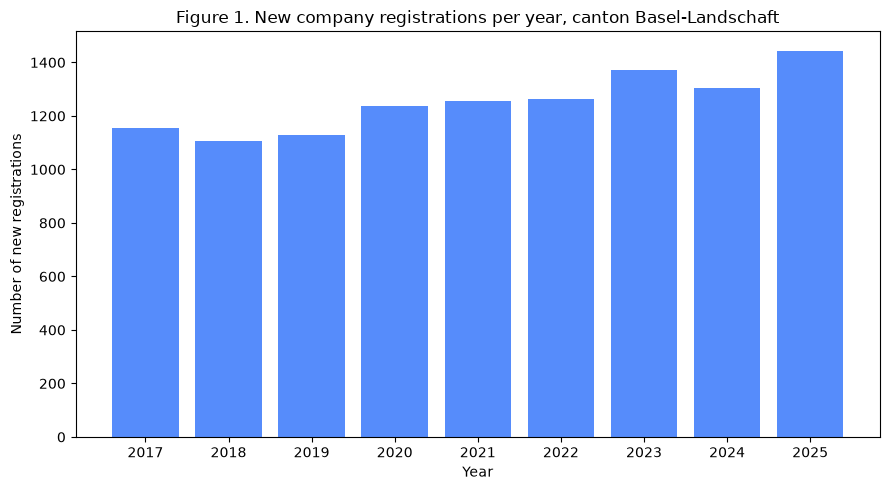

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(yearly_counts.index.astype(str), yearly_counts.values)
ax.set_title("Figure 1. New company registrations per year, canton Basel-Landschaft")
ax.set_xlabel("Year")
ax.set_ylabel("Number of new registrations")
plt.tight_layout()
plt.show()

**Interpretation:** The yearly volume grows from 1,156 registrations in 2017 to 1,444 in 2025, with small dips in 2018 and 2024. The chart shows that the denominator of the AG share grew by roughly a quarter over the window, so the share comparison happens against a rising base.

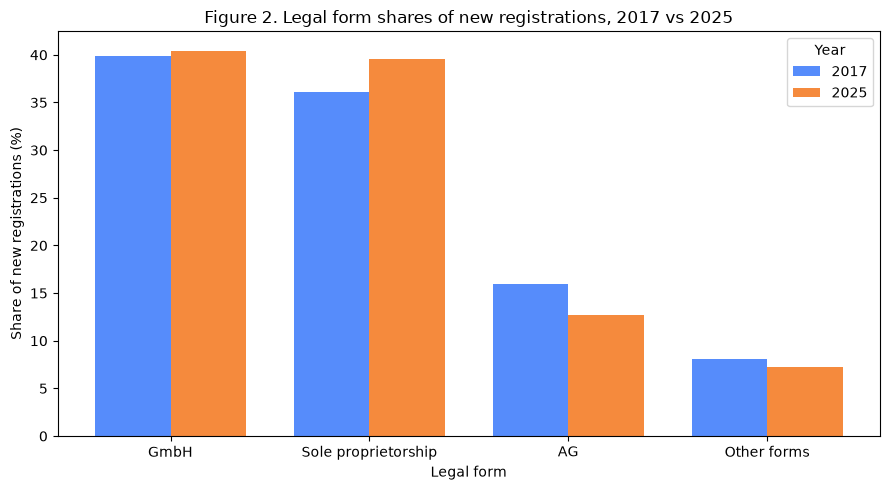

In [20]:
top_forms = [
    "Gesellschaft mit beschränkter Haftung (GmbH)",
    "Einzelunternehmen",
    "Aktiengesellschaft (AG)",
]
shares = {}
for year in (2017, 2025):
    year_data = new_regs[new_regs["year"] == year]
    share = year_data["rechtsform"].value_counts(normalize=True) * 100
    share = share.reindex(top_forms)
    shares[year] = list(share.values) + [100 - share.sum()]

labels = ["GmbH", "Sole proprietorship", "AG", "Other forms"]
x = np.arange(len(labels))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, shares[2017], width, label="2017")
ax.bar(x + width / 2, shares[2025], width, label="2025")
ax.set_title("Figure 2. Legal form shares of new registrations, 2017 vs 2025")
ax.set_xlabel("Legal form")
ax.set_ylabel("Share of new registrations (%)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title="Year")
plt.tight_layout()
plt.show()

**Interpretation:** The GmbH share is nearly unchanged at 39.9% versus 40.4%, while the sole proprietorship share rises from 36.1% to 39.5%. The AG moves in the opposite direction, from 16.0% down to 12.7%, so the largest opposing movements are the rise of the sole proprietorships and the decline of the AG. The chart also shows that the three top forms cover more than 90% of all new registrations in both years.

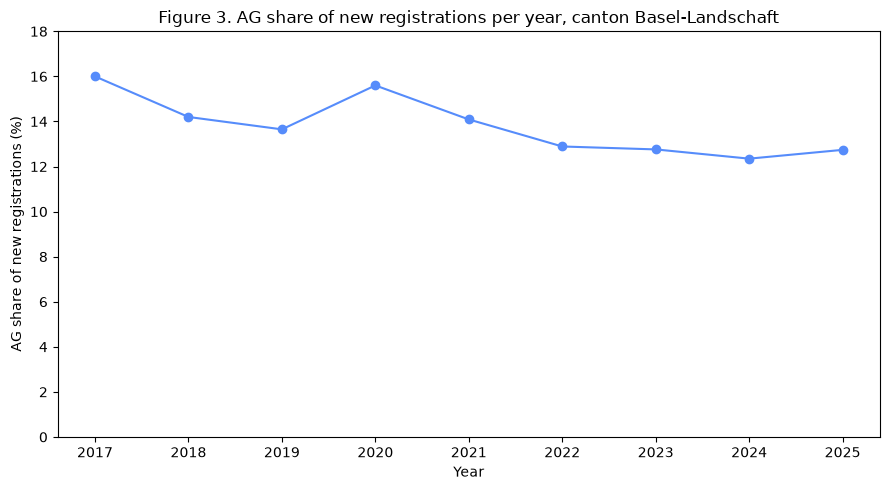

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ag_per_year.index, ag_per_year["ag_share_pct"], marker="o")
ax.set_title("Figure 3. AG share of new registrations per year, canton Basel-Landschaft")
ax.set_xlabel("Year")
ax.set_ylabel("AG share of new registrations (%)")
ax.set_ylim(0, 18)
plt.tight_layout()
plt.show()

**Interpretation:** The AG share falls from 16.0% in 2017 to 12.7% in 2025. The fall is not a straight line, 2020 jumps back to 15.6%, but from 2020 on the overall pattern is downward. The lowest value is 12.35% in 2024, followed by a small uptick to 12.7% in 2025.

### Comparing the three visual models

Figure 1 models the volume of new registrations over time. It reveals the growing base but says nothing about legal forms. Figure 2 models the composition of the registrations and reveals that the largest opposing movements are the rise of the sole proprietorships and the decline of the AG, but it shows just two snapshots and hides everything between 2017 and 2025. Figure 3 models the AG share as a time series and reveals both the size and the timing of the change, at the cost of hiding the absolute numbers behind the share.

**Which model best supports the analytical question:** Figure 3. My question is exactly about the AG share over time, and Figure 3 plots this quantity directly for every year, so a reader sees the starting level, the end level and the path between them in one view. Figures 1 and 2 are the necessary context, Figure 1 explains the growing denominator and Figure 2 rules out that all forms shifted equally.